# Importing Library and Importing the sample file


In [1]:
import pandas as pd

emp_data = pd.read_csv("sample_employee_dataset_.csv")
emp_data

,Employee ID,Name,Age,Department,Salary ($),Years at Company,Performance Score,Attrition
0,E0001,Oscar Walker,35,Finance,83073,17,4.2,Yes
1,E0002,Hannah Patel,43,Finance,61105,19,4.6,No
2,E0003,Nina Scott,26,Human Resources,54998,6,4.2,No
3,E0004,Bob Clark,55,Customer Support,106850,11,4.0,No
4,E0005,Hannah Hall,59,Finance,55421,0,4.5,No
...,...,...,...,...,...,...,...,...
3249,E3250,Nina Kim,46,Marketing,53870,9,4.1,No
3250,E3251,Dana Kim,40,Finance,79577,3,3.3,No
3251,E3252,Nina Scott,36,Customer Support,84511,7,4.0,No
3252,E3253,Oscar Allen,49,Customer Support,72456,13,2.8,No


# Checking the duplicate the values and removing the unnecessary columns 

In [2]:
print(emp_data.duplicated().sum())

0


In [3]:
emp_data

,Employee ID,Name,Age,Department,Salary ($),Years at Company,Performance Score,Attrition
0,E0001,Oscar Walker,35,Finance,83073,17,4.2,Yes
1,E0002,Hannah Patel,43,Finance,61105,19,4.6,No
2,E0003,Nina Scott,26,Human Resources,54998,6,4.2,No
3,E0004,Bob Clark,55,Customer Support,106850,11,4.0,No
4,E0005,Hannah Hall,59,Finance,55421,0,4.5,No
...,...,...,...,...,...,...,...,...
3249,E3250,Nina Kim,46,Marketing,53870,9,4.1,No
3250,E3251,Dana Kim,40,Finance,79577,3,3.3,No
3251,E3252,Nina Scott,36,Customer Support,84511,7,4.0,No
3252,E3253,Oscar Allen,49,Customer Support,72456,13,2.8,No


# Performing Exploratory Data Analysis (EDA) (calculating Mean,Median,Mode)

In [4]:
corr = emp_data.describe()
corr

,Age,Salary ($),Years at Company,Performance Score
count,3254.000000,3254.000000,3254.000000,3254.000000
mean,41.301168,83139.367548,10.055624,4.001076
std,11.185066,22009.555668,6.031196,0.494528
min,22.000000,45005.000000,0.000000,2.100000
25%,32.000000,64350.000000,5.000000,3.700000
50%,41.000000,83342.000000,10.000000,4.000000
75%,51.000000,102467.000000,15.000000,4.300000
max,60.000000,119996.000000,20.000000,5.000000


##              This result suggest that the Avarage age of people in the company is 41 years among which 25% are under 32 year,50% are under 41 year and 75% are 51 years,they serve the company in an average of 10 years where as 25% have serve less than 5 years, 50% have serve almost 10 years and 75% have severd for 15 years with the performance score of 4 in which 25% employee have performance score of 3.7, 50% median score of 4 and 75% have les than 4.3.

### the maximum age of the employee is 60, Highest salary is almost 120000 and max year of serving in company is 20 years with the performance score of 5

In [5]:
corr_emp_data=emp_data[['Age','Salary ($)','Years at Company','Performance Score']].corr()
corr_emp_data

,Age,Salary ($),Years at Company,Performance Score
Age,1.000000,-0.016092,-0.024099,0.006733
Salary ($),-0.016092,1.000000,-0.004389,-0.005688
Years at Company,-0.024099,-0.004389,1.000000,-0.008523
Performance Score,0.006733,-0.005688,-0.008523,1.000000


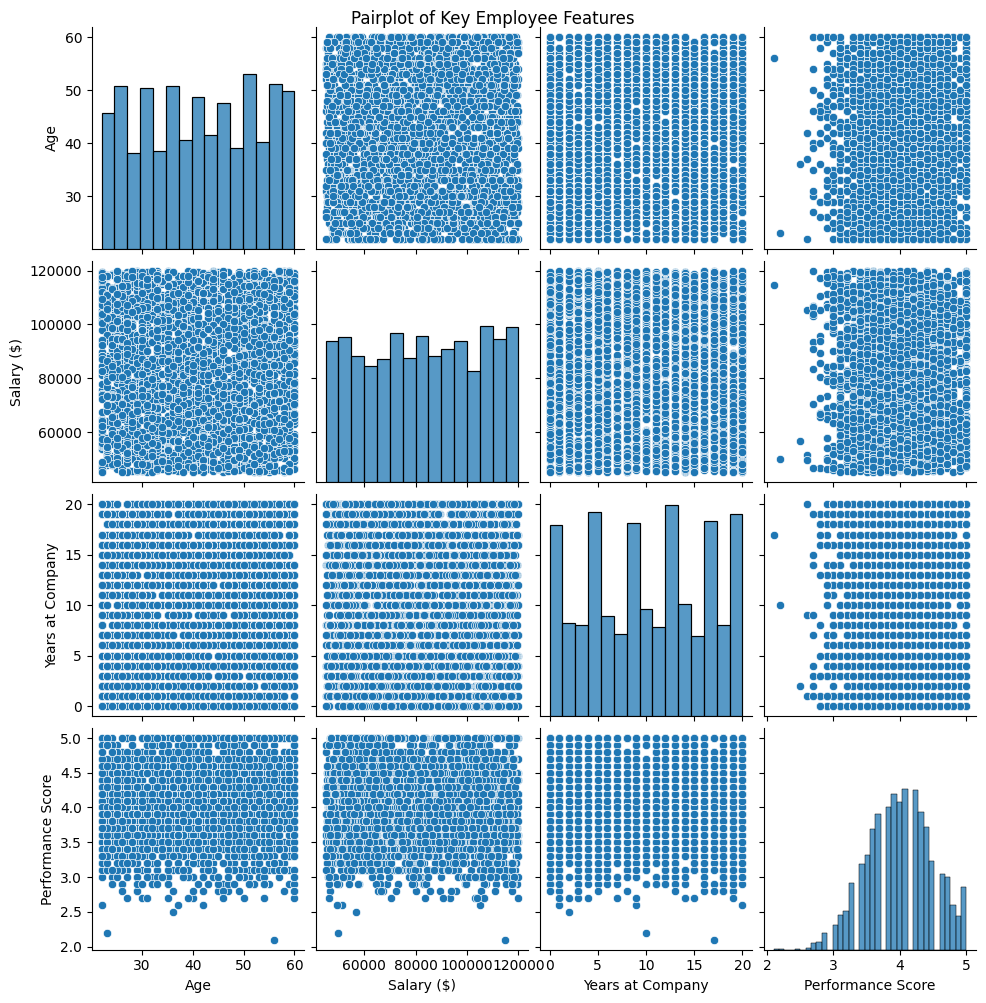

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(emp_data[['Age','Salary ($)','Years at Company','Performance Score']])
plt.suptitle('Pairplot of Key Employee Features', y=1)
plt.show()

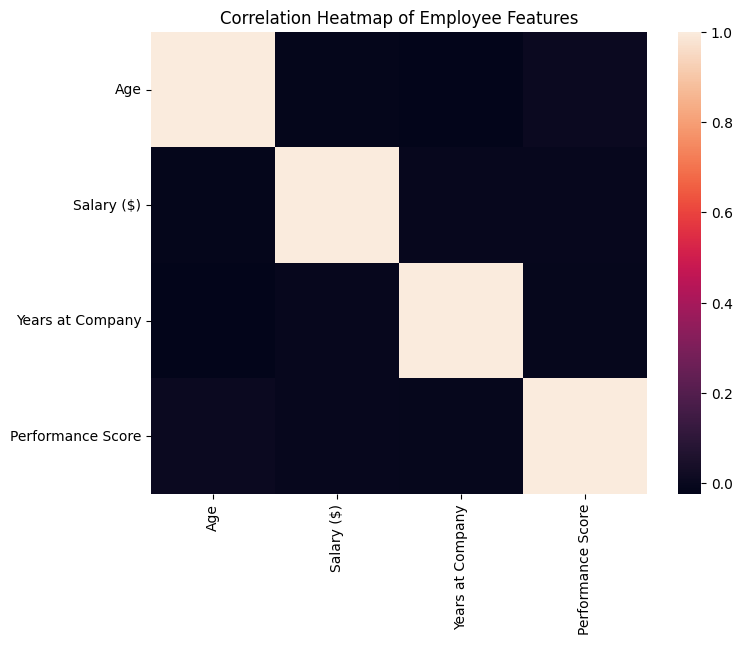

In [7]:
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.heatmap(corr_emp_data)
plt.title('Correlation Heatmap of Employee Features')
plt.show()

# BoxPlot 

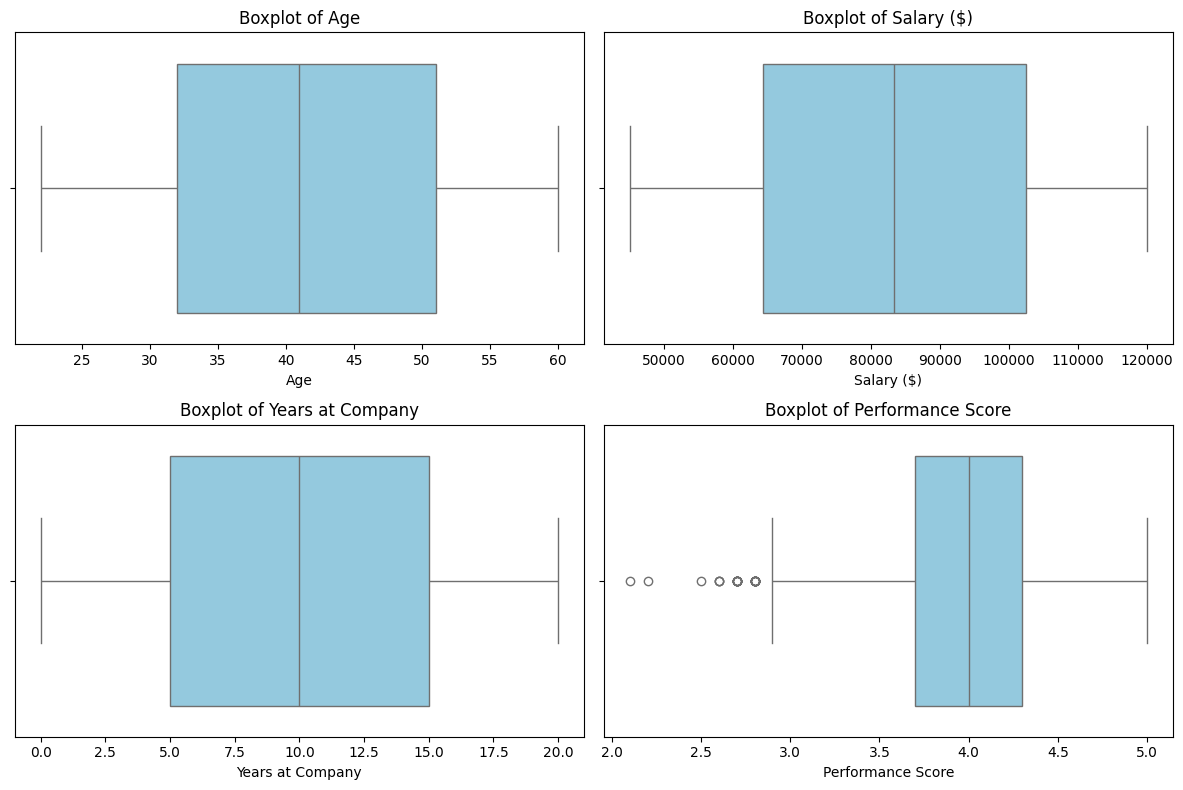

In [8]:
numeric_cols = ['Age', 'Salary ($)', 'Years at Company', 'Performance Score']

plt.figure(figsize=(12, 8))

for i, col in enumerate(numeric_cols, start=1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=emp_data[col], color='skyblue', whis=1.5)
    plt.title(f'Boxplot of {col}')
    
plt.tight_layout()
plt.show()

# Probability of Leaving

In [9]:
emp_data['Left'] = emp_data['Attrition'].map({'Yes':1, 'No':0})
emp_data['Perf_bin'] = pd.cut(emp_data['Performance Score'], bins=[0,3,4,5], labels=['Low','Medium','High'])
prob_df = (
    emp_data.groupby(['Department','Perf_bin'])['Left']
    .agg(['mean','count'])
    .rename(columns={'mean':'Prob_left','count':'N'})
    .reset_index()
)
print(prob_df)


          Department Perf_bin  Prob_left    N
0   Customer Support      Low   0.076923   13
1   Customer Support   Medium   0.214912  228
2   Customer Support     High   0.178082  219
3        Engineering      Low   0.111111    9
4        Engineering   Medium   0.200000  250
5        Engineering     High   0.240741  216
6            Finance      Low   0.066667   15
7            Finance   Medium   0.211009  218
8            Finance     High   0.198980  196
9    Human Resources      Low   0.214286   14
10   Human Resources   Medium   0.241379  232
11   Human Resources     High   0.232759  232
12                IT      Low   0.111111    9
13                IT   Medium   0.169421  242
14                IT     High   0.175115  217
15         Marketing      Low   0.125000   16
16         Marketing   Medium   0.252212  226
17         Marketing     High   0.246445  211
18             Sales      Low   0.157895   19
19             Sales   Medium   0.181034  232
20             Sales     High   0.

C:\Users\tbira\AppData\Local\Temp\ipykernel_15744\401102564.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  emp_data.groupby(['Department','Perf_bin'])['Left']


# Bayes Therom

In [10]:
p_left = emp_data['Left'].mean()
likelihood = (
    emp_data[emp_data['Left']==1]
    .groupby('Perf_bin')['Left']
    .count() / emp_data['Left'].sum()
)
evidence = emp_data.groupby('Perf_bin')['Left'].count() / len(emp_data)
bayes = (likelihood * p_left) / evidence
print(bayes)

Perf_bin
Low       0.126316
Medium    0.209459
High      0.213586
Name: Left, dtype: float64


C:\Users\tbira\AppData\Local\Temp\ipykernel_15744\2461238685.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('Perf_bin')['Left']
C:\Users\tbira\AppData\Local\Temp\ipykernel_15744\2461238685.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  evidence = emp_data.groupby('Perf_bin')['Left'].count() / len(emp_data)


# Scaling Numerical Features

In [11]:
from sklearn.preprocessing import StandardScaler
num_features = ['Age', 'Salary ($)', 'Years at Company', 'Performance Score']
scaler = StandardScaler()
emp_data[num_features] = scaler.fit_transform(emp_data[num_features])

# Labeling and Encoding (Categorical data)

In [12]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
emp_data['Attrition_encoded'] = le.fit_transform(emp_data['Attrition'])  
emp_data['Department_encoded'] = le.fit_transform(emp_data['Department'])
emp_data_ml = emp_data.drop(columns=['Attrition', 'Department', 'Perf_bin'])
print(emp_data_ml.head())

  Employee ID          Name       Age  Salary ($)  Years at Company  \
0       E0001  Oscar Walker -0.563442   -0.003016          1.151586   
1       E0002  Hannah Patel  0.151907   -1.001281          1.483247   
2       E0003    Nina Scott -1.368210   -1.278794         -0.672544   
3       E0004     Bob Clark  1.224931    1.077454          0.156606   
4       E0005   Hannah Hall  1.582606   -1.259572         -1.667525   

   Performance Score  Left  Attrition_encoded  Department_encoded  
0           0.402313     1                  1                   2  
1           1.211290     0                  0                   2  
2           0.402313     0                  0                   3  
3          -0.002175     0                  0                   0  
4           1.009046     0                  0                   2  


# Train/Test Dataset 


In [13]:
from sklearn.model_selection import train_test_split
X = emp_data_ml.drop(columns=['Left', 'Employee ID','Name'])
y = emp_data_ml['Left']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
print(emp_data_ml.columns)

Index(['Employee ID', 'Name', 'Age', 'Salary ($)', 'Years at Company',
       'Performance Score', 'Left', 'Attrition_encoded', 'Department_encoded'],
      dtype='object')


# Trainnin Classification Model


In [15]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

# Evaluatin the modle

In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       512
           1       1.00      1.00      1.00       139

    accuracy                           1.00       651
   macro avg       1.00      1.00      1.00       651
weighted avg       1.00      1.00      1.00       651



# visualization

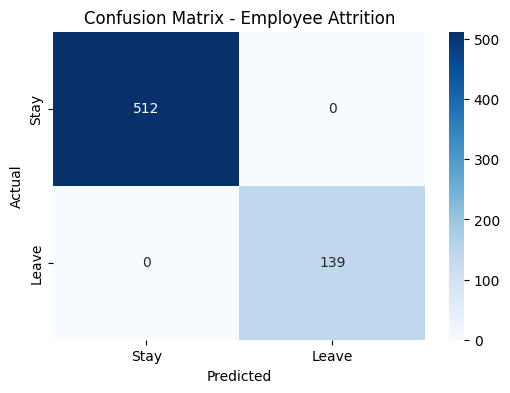

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stay', 'Leave'], yticklabels=['Stay', 'Leave'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Employee Attrition')
plt.show()

# Prepare Data 

In [18]:
from sklearn.model_selection import train_test_split


y_perf = emp_data_ml['Performance Score']
X_perf = emp_data_ml.drop(columns=['Employee ID','Performance Score','Name'])
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X_perf, y_perf, test_size=0.2, random_state=42)

# usin linear reression model

In [19]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train_p, y_train_p)

y_pred_p = lr_model.predict(X_test_p)

# Evaluation 

In [20]:
from sklearn.metrics import r2_score, mean_squared_error

r2 = r2_score(y_test_p, y_pred_p)
mse = mean_squared_error(y_test_p, y_pred_p)

print("R-squared (R²):", r2)
print("Mean Squared Error (MSE):", mse)


R-squared (R²): 0.0016524071100597615
Mean Squared Error (MSE): 1.022444774733074


# visualation

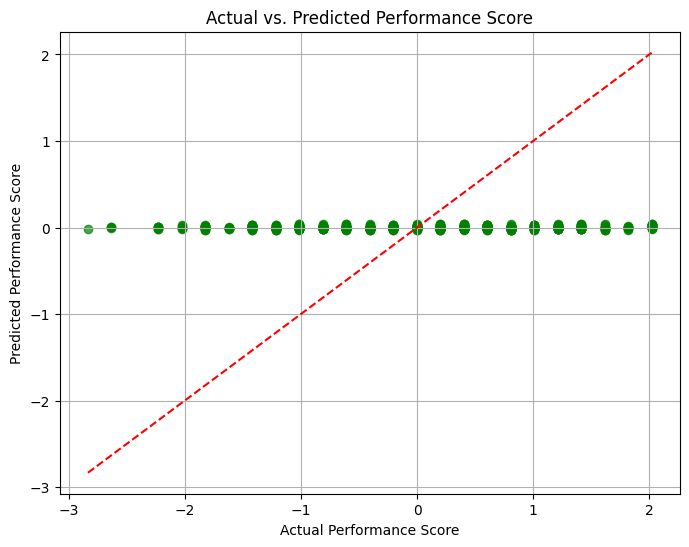

In [21]:

plt.figure(figsize=(8, 6))
plt.scatter(y_test_p, y_pred_p, alpha=0.7, color='green')
plt.plot([y_test_p.min(), y_test_p.max()], [y_test_p.min(), y_test_p.max()], 'r--')  # 45-degree line
plt.xlabel('Actual Performance Score')
plt.ylabel('Predicted Performance Score')
plt.title('Actual vs. Predicted Performance Score')
plt.grid(True)
plt.show()

In [22]:
from sklearn.linear_model import LinearRegression

# Feedforward

In [23]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import StandardScaler

X = emp_data_ml.drop(columns=['Employee ID','Performance Score','Name'])
y = emp_data_ml['Performance Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = Sequential([
    Dense(64, input_dim=X_train.shape[1], activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)  
])

model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

history = model.fit(X_train, y_train, epochs=15, batch_size=32, validation_split=0.2, verbose=1)


ModuleNotFoundError: No module named 'tensorflow'

# Evaluate

In [ ]:
loss, mae = model.evaluate(X_test, y_test)
print(f"Test MSE: {loss}")
print(f"Test MAE: {mae}")


# Plot

In [ ]:
y_pred_nn = model.predict(X_test).flatten()

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_nn, alpha=0.7, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Performance Score')
plt.ylabel('Predicted (NN)')
plt.title('Neural Network - Actual vs Predicted Performance')
plt.grid(True)
plt.show()
